## LSTM and ConvNet Based Architecture for $P(C_t)$ as a Probability Map


### Comparison between:
- only $t_0$
- $t_0$ and $t_{-1}$ with a step of one hour 
- $t_0$, $t_{-1}$  and $t_{-2}$ with a step of 30 minutes

Five time steps, 15 minutes up to $t_0$

## Imports

In [1]:
import pandas as pd                                                                     # type: ignore
import matplotlib.pyplot as plt                                                         # type: ignore
import seaborn as sns                                                                   # type: ignore
import numpy as np                                                                      # type: ignore
from  sklearn import metrics                                                            # type: ignore
from sklearn.preprocessing import StandardScaler                                        # type: ignore
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss                  # type: ignore
import tensorflow as tf                                                                 # type: ignore
import matplotlib as mpl                                                                # type: ignore
from joblib import load                                                                 # type: ignore

2024-10-30 10:07:28.304670: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-10-30 10:07:28.309446: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-10-30 10:07:28.380391: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-30 10:07:31.217278: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
font = {'family' : 'serif',
        'weight' : 'normal',
        'size'   : 9}

mpl.rc('font', **font)

axis_font = {'family': 'serif',
             'color':  'black',
             'weight': 'normal',
             'size': 12,
            }

### This depends on the grid spacing

### Read data

These are the appropriate data for the map, corrected from outliers 

In [3]:
test_data_X_lt1 = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/map/2h-before/csv-data/test-Dakar-map-features-many-timesteps-30min-lt1-2h-before.csv", index_col=False)
test_data_y_lt1 = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/map/2h-before/csv-data/test-Dakar-map-target-many-timesteps-30min-lt1-2h-before.csv", index_col=False)

In [4]:
test_data_X_lt3 = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/map/2h-before/csv-data/test-Dakar-map-features-many-timesteps-30min-lt3-2h-before.csv", index_col=False)
test_data_y_lt3 = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/map/2h-before/csv-data/test-Dakar-map-target-many-timesteps-30min-lt3-2h-before.csv", index_col=False)

### Defining and choosing headers for each timesteps

#### 2 hours before with a time step of 30 minutes

In [5]:
# Initial headers for time periods
t0 = "year,month,day,hour,minute,"
t30 = "year_30,month_30,day_30,hour_30,minute_30,"
t60 = "year_60,month_60,day_60,hour_60,minute_60,"
t90 = "year_90,month_90,day_90,hour_90,minute_90,"
t120 = "year_120,month_120,day_120,hour_120,minute_120,"

# Initialize empty strings for loc, wp, ds, sz for t0 (current), t30, t60, t90, and t120
loc = wp = ds = sz = "" 
loc_30 = wp_30 = ds_30 = sz_30 = "" 
loc_60 = wp_60 = ds_60 = sz_60 = "" 
loc_90 = wp_90 = ds_90 = sz_90 = "" 
loc_120 = wp_120 = ds_120 = sz_120 = "" 

# Loop to generate the string for each time period (current, +30, +60, +90, +120 minutes)
for i in range(1, 6):
    # For the current time (t0)
    loc += f"lat{i},lon{i},"
    wp += f"wp{i},"
    ds += f"ds{i},"
    sz += f"size{i},"
    
    # For t30 (30 minutes later)
    loc_30 += f"lat{i}_30,lon{i}_30,"
    wp_30 += f"wp{i}_30,"
    ds_30 += f"ds{i}_30,"
    sz_30 += f"size{i}_30,"
    
    # For t60 (60 minutes later)
    loc_60 += f"lat{i}_60,lon{i}_60,"
    wp_60 += f"wp{i}_60,"
    ds_60 += f"ds{i}_60,"
    sz_60 += f"size{i}_60,"
    
    # For t90 (90 minutes later)
    loc_90 += f"lat{i}_90,lon{i}_90,"
    wp_90 += f"wp{i}_90,"
    ds_90 += f"ds{i}_90,"
    sz_90 += f"size{i}_90,"
    
    # For t120 (120 minutes later)
    loc_120 += f"lat{i}_120,lon{i}_120,"
    wp_120 += f"wp{i}_120,"
    ds_120 += f"ds{i}_120,"
    sz_120 += f"size{i}_120,"

headers_2hb = (t0 + loc + wp + sz + ds + 
           t30 + loc_30 + wp_30 + sz_30 + ds_30 + 
           t60 + loc_60 + wp_60 + sz_60 + ds_60 + 
           t90 + loc_90 + wp_90 + sz_90 + ds_90 + 
           t120 + loc_120 + wp_120 + sz_120 + ds_120)

print(headers_2hb)


year,month,day,hour,minute,lat1,lon1,lat2,lon2,lat3,lon3,lat4,lon4,lat5,lon5,wp1,wp2,wp3,wp4,wp5,size1,size2,size3,size4,size5,ds1,ds2,ds3,ds4,ds5,year_30,month_30,day_30,hour_30,minute_30,lat1_30,lon1_30,lat2_30,lon2_30,lat3_30,lon3_30,lat4_30,lon4_30,lat5_30,lon5_30,wp1_30,wp2_30,wp3_30,wp4_30,wp5_30,size1_30,size2_30,size3_30,size4_30,size5_30,ds1_30,ds2_30,ds3_30,ds4_30,ds5_30,year_60,month_60,day_60,hour_60,minute_60,lat1_60,lon1_60,lat2_60,lon2_60,lat3_60,lon3_60,lat4_60,lon4_60,lat5_60,lon5_60,wp1_60,wp2_60,wp3_60,wp4_60,wp5_60,size1_60,size2_60,size3_60,size4_60,size5_60,ds1_60,ds2_60,ds3_60,ds4_60,ds5_60,year_90,month_90,day_90,hour_90,minute_90,lat1_90,lon1_90,lat2_90,lon2_90,lat3_90,lon3_90,lat4_90,lon4_90,lat5_90,lon5_90,wp1_90,wp2_90,wp3_90,wp4_90,wp5_90,size1_90,size2_90,size3_90,size4_90,size5_90,ds1_90,ds2_90,ds3_90,ds4_90,ds5_90,year_120,month_120,day_120,hour_120,minute_120,lat1_120,lon1_120,lat2_120,lon2_120,lat3_120,lon3_120,lat4_120,lon4_120,lat5_120,lon5_120,wp1_1

#### 1 hour before with a time step of 1h

In [6]:
# Initial headers for time periods
t0 = "year,month,day,hour,minute,"
t60 = "year_60,month_60,day_60,hour_60,minute_60,"

# Initialize empty strings for loc, wp, ds, sz for t0 (current) and t60
loc = wp = ds = sz = "" 
loc_60 = wp_60 = ds_60 = sz_60 = "" 

# Loop to generate the string for each time period (current and +60 minutes)
for i in range(1, 6):
    # For the current time (t0)
    loc += f"lat{i},lon{i},"
    wp += f"wp{i},"
    sz += f"size{i},"
    ds += f"ds{i},"
    
    # For t60 (60 minutes later)
    loc_60 += f"lat{i}_60,lon{i}_60,"
    wp_60 += f"wp{i}_60,"
    sz_60 += f"size{i}_60,"
    ds_60 += f"ds{i}_60,"

# Concatenate headers for t0 and t60, ensuring that sz appears before ds
headers_1hb = t0 + loc + wp + sz + ds + t60 + loc_60 + wp_60 + sz_60 + ds_60

print(headers_1hb)


year,month,day,hour,minute,lat1,lon1,lat2,lon2,lat3,lon3,lat4,lon4,lat5,lon5,wp1,wp2,wp3,wp4,wp5,size1,size2,size3,size4,size5,ds1,ds2,ds3,ds4,ds5,year_60,month_60,day_60,hour_60,minute_60,lat1_60,lon1_60,lat2_60,lon2_60,lat3_60,lon3_60,lat4_60,lon4_60,lat5_60,lon5_60,wp1_60,wp2_60,wp3_60,wp4_60,wp5_60,size1_60,size2_60,size3_60,size4_60,size5_60,ds1_60,ds2_60,ds3_60,ds4_60,ds5_60,


#### Only $t_0$

In [7]:
# Initial header for the 60-minute time period
t60 = "year_60,month_60,day_60,hour_60,minute_60,"

# Initialize empty strings for loc, wp, ds, sz for t60
loc_60 = wp_60 = ds_60 = sz_60 = "" 

# Loop to generate the string for each time period (60 minutes later)
for i in range(1, 6):
    # For t60 (60 minutes later)
    loc_60 += f"lat{i}_60,lon{i}_60,"
    wp_60 += f"wp{i}_60,"
    ds_60 += f"ds{i}_60,"
    sz_60 += f"size{i}_60,"

# Concatenate only headers for t60
headers_t0 = t60 + loc_60 + wp_60 + sz_60 + ds_60

print(headers_t0)

year_60,month_60,day_60,hour_60,minute_60,lat1_60,lon1_60,lat2_60,lon2_60,lat3_60,lon3_60,lat4_60,lon4_60,lat5_60,lon5_60,wp1_60,wp2_60,wp3_60,wp4_60,wp5_60,size1_60,size2_60,size3_60,size4_60,size5_60,ds1_60,ds2_60,ds3_60,ds4_60,ds5_60,


In [8]:
raw_test_data_X_lt1_t0 = test_data_X_lt1[headers_t0.split(",")[:-1]]
raw_test_data_X_lt3_t0 = test_data_X_lt3[headers_t0.split(",")[:-1]]

In [9]:
raw_test_data_X_lt1_1hb = test_data_X_lt1[headers_1hb.split(",")[:-1]]
raw_test_data_X_lt3_1hb = test_data_X_lt3[headers_1hb.split(",")[:-1]]

In [10]:
raw_test_data_X_lt1_2hb = test_data_X_lt1[headers_2hb.split(",")[:-1]]
raw_test_data_X_lt3_2hb = test_data_X_lt3[headers_2hb.split(",")[:-1]]

## Preprocessing

In [11]:
def log_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i > 0:
                transformed.append(np.log(i))
            else:
                transformed.append(np.log(i+1e-8))    
        df_copy[key] = transformed
    return df_copy

In [12]:
def sqrt_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i >= 0:
                transformed.append(np.sqrt(i)) 
        df_copy[key] = transformed
    return df_copy

2 hours before

In [13]:
# Concatenate headers for wp, sz, and ds across time periods with updated intervals
to_scale_2hb = f"{wp}{wp_30}{wp_60}{wp_90}{wp_120}{sz}{sz_30}{sz_60}{sz_90}{sz_120}{ds}{ds_30}{ds_60}{ds_90}{ds_120}".rstrip(',')

# Concatenate headers for time variables with updated intervals
t_2hb = f"{t0}{t30}{t60}{t90}{t120}".rstrip(',')

print(to_scale_2hb)
print(t_2hb)


wp1,wp2,wp3,wp4,wp5,wp1_30,wp2_30,wp3_30,wp4_30,wp5_30,wp1_60,wp2_60,wp3_60,wp4_60,wp5_60,wp1_90,wp2_90,wp3_90,wp4_90,wp5_90,wp1_120,wp2_120,wp3_120,wp4_120,wp5_120,size1,size2,size3,size4,size5,size1_30,size2_30,size3_30,size4_30,size5_30,size1_60,size2_60,size3_60,size4_60,size5_60,size1_90,size2_90,size3_90,size4_90,size5_90,size1_120,size2_120,size3_120,size4_120,size5_120,ds1,ds2,ds3,ds4,ds5,ds1_30,ds2_30,ds3_30,ds4_30,ds5_30,ds1_60,ds2_60,ds3_60,ds4_60,ds5_60,ds1_90,ds2_90,ds3_90,ds4_90,ds5_90,ds1_120,ds2_120,ds3_120,ds4_120,ds5_120
year,month,day,hour,minute,year_30,month_30,day_30,hour_30,minute_30,year_60,month_60,day_60,hour_60,minute_60,year_90,month_90,day_90,hour_90,minute_90,year_120,month_120,day_120,hour_120,minute_120


1 hour before

In [14]:
# Concatenate headers for wp, sz, and ds for only t0 and t60 intervals
to_scale_1hb = f"{wp}{wp_60}{sz}{sz_60}{ds}{ds_60}".rstrip(',')

# Concatenate headers for time variables for only t0 and t60 intervals
t_1hb = f"{t0}{t60}".rstrip(',')

#print(to_scale_1hb)
print(t_1hb)

year,month,day,hour,minute,year_60,month_60,day_60,hour_60,minute_60


Only $t_0$

In [15]:
to_scale_t0 = f"{wp_60}{sz_60}{ds_60}".rstrip(',')

# Concatenate headers for time variables for only the t60 interval
t_0 = f"{t60}".rstrip(',')

print(to_scale_t0)
print(t_0)


wp1_60,wp2_60,wp3_60,wp4_60,wp5_60,size1_60,size2_60,size3_60,size4_60,size5_60,ds1_60,ds2_60,ds3_60,ds4_60,ds5_60
year_60,month_60,day_60,hour_60,minute_60


In [16]:
def prepare_for_test(dataframe, to_scale, t):
    df = dataframe.copy()
    df = log_transform(df, to_scale.split(','))
    df = sqrt_transform(df, t.split(','))
    return df

In [17]:
t_1hb

'year,month,day,hour,minute,year_60,month_60,day_60,hour_60,minute_60'

### Transforming

In [18]:
transform = True

if transform:   
    test_data_X_lt1_2hb = prepare_for_test(raw_test_data_X_lt1_2hb, to_scale_2hb, t_2hb)
    test_data_X_lt1_1hb = prepare_for_test(raw_test_data_X_lt1_1hb, to_scale_1hb, t_1hb)
    test_data_X_lt1_t0 = prepare_for_test(raw_test_data_X_lt1_t0, to_scale_t0, t_0)

    test_data_X_lt3_2hb = prepare_for_test(raw_test_data_X_lt3_2hb, to_scale_2hb, t_2hb)
    test_data_X_lt3_1hb = prepare_for_test(raw_test_data_X_lt3_1hb, to_scale_1hb, t_1hb)
    test_data_X_lt3_t0 = prepare_for_test(raw_test_data_X_lt3_t0, to_scale_t0, t_0)

### Scaling

2 hours before

In [19]:
scaler_lt1_2hb = load(f'Dakar-map-lt1-lstm-2h-before.bin')
model_lt1_2hb = tf.keras.models.load_model(f'Dakar-map-lt1-lstm-2h-before.keras')

scaler_lt3_2hb = load(f'Dakar-map-lt3-lstm-2h-before.bin')
model_lt3_2hb = tf.keras.models.load_model(f'Dakar-map-lt3-lstm-2h-before.keras')

1 hour before

In [20]:
scaler_lt1_1hb = load(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/map/1h-before/Dakar-map-lt1-lstm-1h-before.bin')
model_lt1_1hb = tf.keras.models.load_model(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/map/1h-before/Dakar-map-lt1-lstm-1h-before.keras')

scaler_lt3_1hb = load(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/map/1h-before/Dakar-map-lt3-lstm-1h-before.bin')
model_lt3_1hb = tf.keras.models.load_model(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/map/1h-before/Dakar-map-lt3-lstm-1h-before.keras')

Only $t_0$

In [21]:
scaler_lt1_t0 = load(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/map/scaler-Dakar-map-t1.bin')
model_lt1_t0 = tf.keras.models.load_model(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/map/Dakar-map-t1.keras')

scaler_lt3_t0 = load(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/map/scaler-Dakar-map-t3.bin')
model_lt3_t0 = tf.keras.models.load_model(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/map/Dakar-map-t3.keras')

In [22]:
std_x_lt1_2hb = scaler_lt1_2hb.transform(test_data_X_lt1_2hb)
std_x_lt3_2hb = scaler_lt3_2hb.transform(test_data_X_lt3_2hb)

In [23]:
std_x_lt1_1hb = scaler_lt1_1hb.transform(test_data_X_lt1_1hb)
std_x_lt3_1hb = scaler_lt3_1hb.transform(test_data_X_lt3_1hb)

In [24]:
new_column_names = {col: col.replace('_60', '') for col in test_data_X_lt1_t0.columns}
test_data_X_lt1_t0.rename(columns=new_column_names, inplace=True)

In [25]:
new_column_names = {col: col.replace('_60', '') for col in test_data_X_lt3_t0.columns}
test_data_X_lt3_t0.rename(columns=new_column_names, inplace=True)

In [26]:
std_x_lt1_t0 = scaler_lt1_t0.transform(test_data_X_lt1_t0)
std_x_lt3_t0 = scaler_lt3_t0.transform(test_data_X_lt3_t0)

In [27]:
resolution = 11

In [28]:
x_test_lt1_2hb = std_x_lt1_2hb.reshape(len(test_data_X_lt1_2hb), 5, 30)
x_test_lt3_2hb = std_x_lt3_2hb.reshape(len(test_data_X_lt3_2hb), 5, 30)

x_test_lt1_1hb = std_x_lt1_1hb.reshape(len(test_data_X_lt1_1hb), 2, 30)
x_test_lt3_1hb = std_x_lt3_1hb.reshape(len(test_data_X_lt3_1hb), 2, 30)

x_test_lt1_t0 = std_x_lt1_t0
x_test_lt3_t0 = std_x_lt3_t0

In [29]:
y_test_t1 = tf.reshape(test_data_y_lt1, (len(test_data_y_lt1), resolution, resolution))
y_test_t3 = tf.reshape(test_data_y_lt3, (len(test_data_y_lt3), resolution, resolution))

2h before

In [30]:
pred_y_test_t1_2hb = model_lt1_2hb.predict(x_test_lt1_2hb).flatten()
pred_y_test_t3_2hb = model_lt3_2hb.predict(x_test_lt3_2hb).flatten()

420/420 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
355/355 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


1h before

In [31]:
pred_y_test_t1_1hb = model_lt1_1hb.predict(x_test_lt1_1hb).flatten()
pred_y_test_t3_1hb = model_lt3_1hb.predict(x_test_lt3_1hb).flatten()

420/420 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


t0

In [32]:
pred_y_test_t1_t0 = model_lt1_t0.predict(x_test_lt1_t0).flatten()
pred_y_test_t3_t0 = model_lt3_t0.predict(x_test_lt3_t0).flatten()

420/420 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


## ROC

Maybe I should also plot the Precision-Recall ROC curve

In [33]:
def plot_roc(name, labels, predictions, **kwargs):
  fp, tp, _ = metrics.roc_curve(labels, predictions)
  plt.plot(100*fp, 100*tp, label=name, linewidth=2, **kwargs)
  plt.xlabel('False alarm [%]')
  plt.ylabel('Hit [%]')
  plt.xlim([0,100])
  plt.ylim([0,100])
  #plt.grid(True)
  ax = plt.gca()
  ax.set_aspect('equal')

In [34]:
auc_test_t1_2hb = roc_auc_score(y_test_t1.numpy().flatten(), pred_y_test_t1_2hb)
auc_test_t3_2hb = roc_auc_score(y_test_t3.numpy().flatten(), pred_y_test_t3_2hb)

auc_test_t1_1hb = roc_auc_score(y_test_t1.numpy().flatten(), pred_y_test_t1_1hb)
auc_test_t3_1hb = roc_auc_score(y_test_t3.numpy().flatten(), pred_y_test_t3_1hb)

auc_test_t1_t0 = roc_auc_score(y_test_t1.numpy().flatten(), pred_y_test_t1_t0)
auc_test_t3_t0 = roc_auc_score(y_test_t3.numpy().flatten(), pred_y_test_t3_t0)

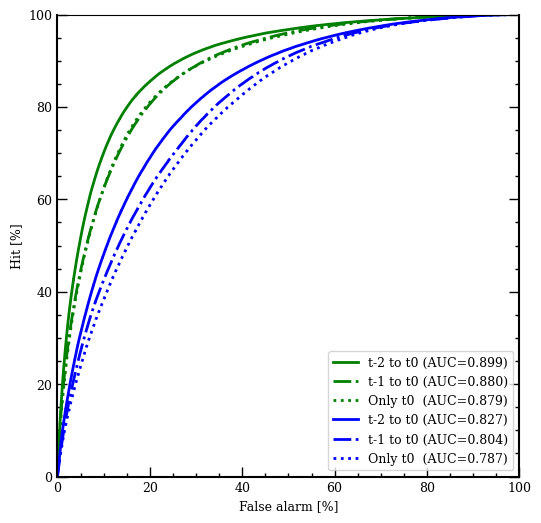

In [35]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

ax.minorticks_on()
ax.tick_params(which='major', length=7, width=1, direction='in',bottom=True, left=True, right=True)
ax.tick_params(which='minor', length=3,  width=1, direction='in',bottom=True, left=True, right=True)

for axis in ['bottom', 'left', 'right']:
	ax.spines[axis].set_linewidth(1.5) 
	ax.spines[axis].set_color('black')

plot_roc(f"t-2 to t0 (AUC={auc_test_t1_2hb:.3f})", y_test_t1.numpy().flatten(), pred_y_test_t1_2hb, color="green", linestyle='-')
plot_roc(f"t-1 to t0 (AUC={auc_test_t1_1hb:.3f})", y_test_t1.numpy().flatten(), pred_y_test_t1_1hb, color="green", linestyle='-.')
plot_roc(f"Only t0  (AUC={auc_test_t1_t0:.3f})", y_test_t1.numpy().flatten(), pred_y_test_t1_t0, color="green", linestyle='dotted')

plot_roc(f"t-2 to t0 (AUC={auc_test_t3_2hb:.3f})", y_test_t3.numpy().flatten(), pred_y_test_t3_2hb, color="blue", linestyle='-')
plot_roc(f"t-1 to t0 (AUC={auc_test_t3_1hb:.3f})", y_test_t3.numpy().flatten(), pred_y_test_t3_1hb, color="blue", linestyle='-.')
plot_roc(f"Only t0  (AUC={auc_test_t3_t0:.3f})", y_test_t3.numpy().flatten(), pred_y_test_t3_t0, color="blue", linestyle='dotted')

plt.legend(loc='lower right');

## Reliability diagram

In [36]:
def reliability_curve(y, y_pred, bin_size=0.1, count_pred_per_bin=100):
  y = np.array(y)
  y_pred = np.array(y_pred)
  bins = np.arange(0, 1+bin_size, bin_size)
  bin_centers = [(b1 + b2) / 2 for b1, b2 in zip(bins[:-1], bins[1:])]
  prop_positive = []
  bin_center_ax = []
  no_pred_per_bin = []
  for b1, b2, bc in zip(bins[:-1], bins[1:], bin_centers):
    in_bin = np.logical_and(y_pred >= b1, y_pred < b2)
    no_predictions_per_bin = np.sum(in_bin)
    no_positive_per_bin = np.sum(y[in_bin])    
    if no_predictions_per_bin > count_pred_per_bin:
      prop_pos = round(no_positive_per_bin/no_predictions_per_bin, 3)
      prop_positive.append(prop_pos)
      bin_center_ax.append(round(bc, 3))
      no_pred_per_bin.append(no_predictions_per_bin)
    else:
      continue
  return bin_center_ax, prop_positive, no_pred_per_bin

In [37]:
def plot_reliability(y_test, pred_y_test, fig_legend, **kwargs):
    prob_pred, prob_true, no_pred_per_bin = reliability_curve(y_test.numpy().flatten(), pred_y_test.flatten())
    plt.plot(prob_pred, prob_true, label=fig_legend, **kwargs)        
    plt.xlabel("Predicted probability")
    plt.ylabel("Obs. proportion of positive case")
    no_pred_per_bin = [i/(1.1*np.max(no_pred_per_bin)) for i in no_pred_per_bin]
    #plt.bar(prob_pred, no_pred_per_bin, width=0.1, linestyle="--", fill=False, edgecolor="green")
    plt.xlim(0,1)
    plt.ylim(0,1)    
    plt.legend()

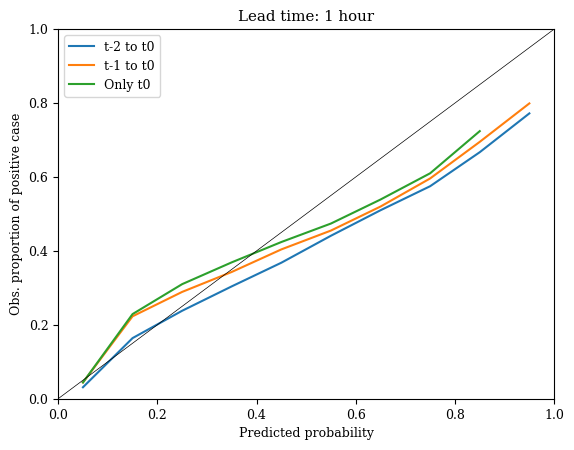

In [38]:
plot_reliability(y_test_t1, pred_y_test_t1_2hb, "t-2 to t0")
plot_reliability(y_test_t1, pred_y_test_t1_1hb, "t-1 to t0")
plot_reliability(y_test_t1, pred_y_test_t1_t0, "Only t0")
plt.plot(np.arange(0,1.2,0.2), np.arange(0,1.2,0.2), color="black", linewidth=0.5)
plt.title("Lead time: 1 hour")
plt.show()

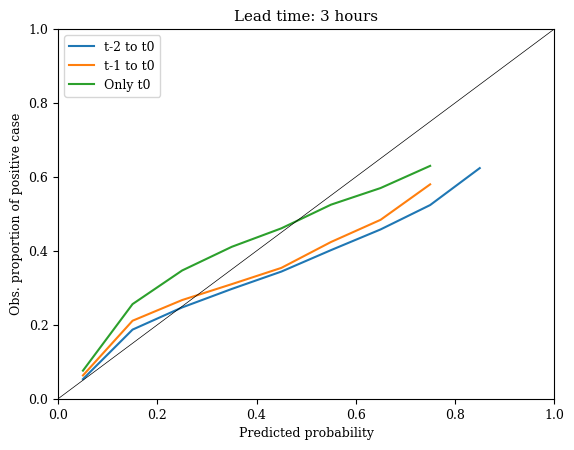

In [39]:
plot_reliability(y_test_t3, pred_y_test_t3_2hb, "t-2 to t0")
plot_reliability(y_test_t3, pred_y_test_t3_1hb, "t-1 to t0")
plot_reliability(y_test_t3, pred_y_test_t3_t0, "Only t0")
plt.plot(np.arange(0,1.2,0.2), np.arange(0,1.2,0.2), color="black", linewidth=0.5)
plt.title("Lead time: 3 hours")
plt.show()

### Verification using Fraction Skill Score

Some other forms of verification may be needed

### FSS

In [40]:
def calculate_fss(forecast, observation, neighborhood_size=1):
    """
    Calculate the Fraction Skill Score (FSS) for a binary forecast and observation over a grid.
    Handles the case where both forecast and observation are all zeros.
    
    Args:
    - forecast (2D numpy array): Binary forecast data (1 for event, 0 for no event).
    - observation (2D numpy array): Binary observation data (1 for event, 0 for no event).
    - neighborhood_size (int): Size of the neighborhood window for fraction calculation.
    
    Returns:
    - FSS (float): The fraction skill score between forecast and observation.
    """
    forecast = np.array(forecast)
    observation = np.array(observation)
    
    if forecast.shape != observation.shape:
        raise ValueError("Forecast and observation must have the same shape.")
    
    # If both forecast and observation are all zeros, return perfect FSS (1)
    if np.all(forecast == 0) and np.all(observation == 0):
        return 1.0
    
    def compute_fraction(data, neighborhood_size):
        rows, cols = data.shape
        fraction = np.zeros_like(data, dtype=float)
        for i in range(rows):
            for j in range(cols):
                r_min = max(0, i - neighborhood_size)
                r_max = min(rows, i + neighborhood_size + 1)
                c_min = max(0, j - neighborhood_size)
                c_max = min(cols, j + neighborhood_size + 1)
                neighborhood = data[r_min:r_max, c_min:c_max]
                fraction[i, j] = np.mean(neighborhood)
        return fraction
    
    forecast_fraction = compute_fraction(forecast, neighborhood_size)
    observation_fraction = compute_fraction(observation, neighborhood_size)
    
    numerator = np.sum((forecast_fraction - observation_fraction) ** 2)
    denominator = np.sum(forecast_fraction ** 2 + observation_fraction ** 2)
    
    # To avoid division by zero, check if denominator is zero
    if denominator == 0:
        return 0.0  # If there's no signal at all, set FSS to 0
    
    fss = 1 - (numerator / denominator)
    return fss


In [41]:
def calculate_fss_for_all_instances(forecasts, observations, neighborhood_size=1):
    """
    Calculate the FSS for each forecast-observation pair in the dataset and return the average FSS.
    
    Args:
    - forecasts (list of 2D numpy arrays): List of forecast grids for all instances.
    - observations (list of 2D numpy arrays): List of observation grids for all instances.
    - neighborhood_size (int): Size of the neighborhood window for fraction calculation.
    
    Returns:
    - average_fss (float): The average FSS over all instances.
    - fss_scores (list of floats): The FSS score for each instance.
    """
    fss_scores = []
    
    # Loop over each forecast-observation pair
    for forecast, observation in zip(forecasts, observations):
        fss = calculate_fss(forecast, observation, neighborhood_size)
        fss_scores.append(fss)
    
    # Compute the average FSS
    average_fss = np.mean(fss_scores)
    
    return average_fss, fss_scores

#### Computing the FSS for different combinations of threshold and spatial scale

In [42]:
thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
number_of_neighbours = [1, 2, 3]

In [43]:
def plot_fss(pred_y_test, y_test):

    n_test = y_test.shape[0]

    fss = []

    for t in thresholds:
        for scale in number_of_neighbours:
            fss.append(calculate_fss_for_all_instances(pred_y_test.reshape(n_test, resolution, resolution)>=t, y_test, neighborhood_size=scale)[0])

    fss_lt = np.array(fss).reshape(len(thresholds), len(number_of_neighbours)).T

    fig, ax = plt.subplots(figsize=(10, 6))
    cax = ax.imshow(fss_lt, cmap='viridis', aspect='auto')

    # Add a colorbar
    cbar = plt.colorbar(cax)
    cbar.set_label('Fraction Skill Score')

    # Annotate each cell with its value, no need for positional adjustment in imshow
    for i in range(fss_lt.shape[0]):
        for j in range(fss_lt.shape[1]):
            value = fss_lt[i, j]
            ax.text(j, i, f'{value:.2f}', 
                    ha='center', va='center', 
                    color='white', fontsize=8)

    ytick_labels = [str(tick) for tick in number_of_neighbours] 
    ax.set_yticks(np.array(number_of_neighbours)-1)
    ax.set_yticklabels(ytick_labels)


    xtick_labels = [str(tick) for tick in thresholds] 
    ax.set_xticks(range(5))
    ax.set_xticklabels(xtick_labels)


    # Set labels and title
    #plt.title(fig_title)
    plt.xlabel('Classification threshold')
    plt.ylabel('Number of neighbourhoods')
    plt.show()

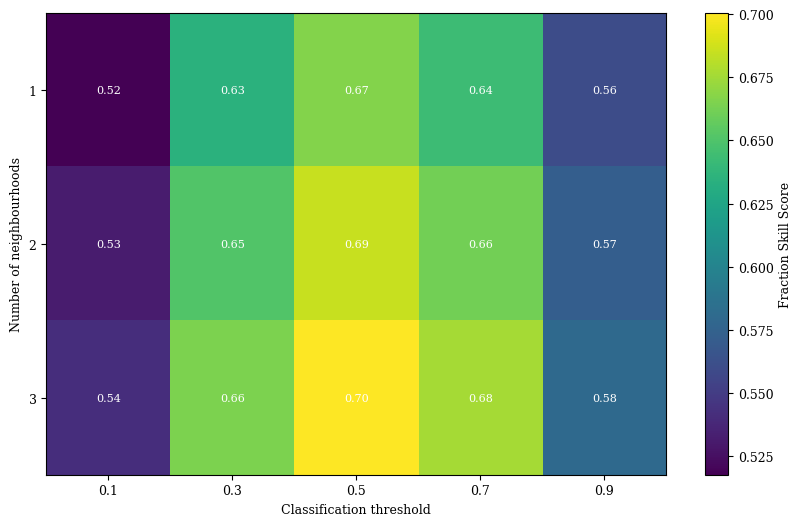

In [44]:
#plot_fss(pred_y_test_t1_2hb, y_test_t1, "Input: t-2 to t0 -- Lead time: 1h")
plot_fss(pred_y_test_t1_2hb, y_test_t1)

In [45]:
#plot_fss(pred_y_test_t1_1hb, y_test_t1, "Input: t-1 to t0 -- Lead time: 1h")

In [46]:
#plot_fss(pred_y_test_t1_t0, y_test_t1, "Input: only t0 -- Lead time: 1h")

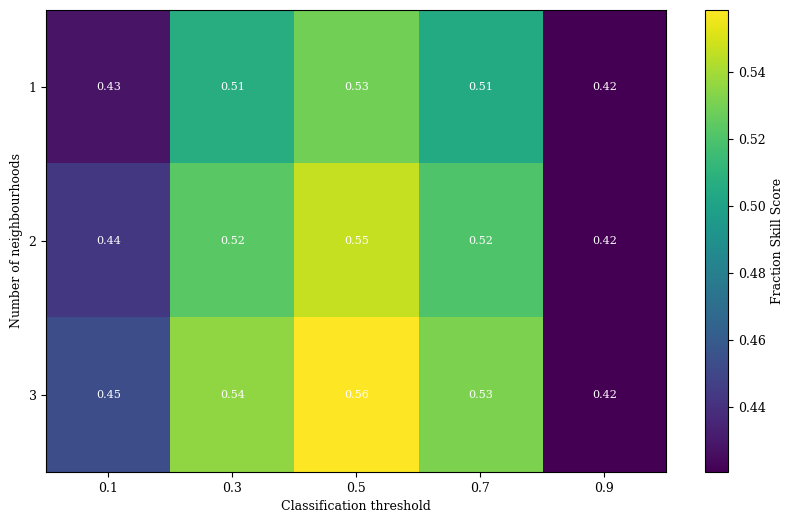

In [47]:
#plot_fss(pred_y_test_t3_2hb, y_test_t3, "Input: t-2 to t0 -- Lead time: 3h")
plot_fss(pred_y_test_t3_2hb, y_test_t3)

In [48]:
#plot_fss(pred_y_test_t3_1hb, y_test_t3, "Input: t-1 to t0 -- Lead time: 1h")

In [49]:
#plot_fss(pred_y_test_t3_t0, y_test_t3, "Input: only t0 -- Lead time: 1h")